# 🏆 Amazon ML Challenge 2025 - Comprehensive EDA
## Smart Product Pricing Challenge

**Team:** Hidden Layers  
**Members:** Yash Maheshwari (Leader), Aaryaman Patti, Raj Badlani  
**Goal:** Predict product prices using catalog text + images (Target SMAPE < 15%)

---

### 📊 Dataset Overview:
- **Training:** 75,000 samples with prices
- **Test:** 75,000 samples for prediction  
- **Features:** catalog_content (text) + image_link (images)
- **Target:** price (USD)
- **Metric:** SMAPE (Symmetric Mean Absolute Percentage Error)

In [1]:
# Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("📦 Libraries loaded successfully!")
print("🎯 Ready for Amazon ML Challenge 2025 EDA")

Matplotlib is building the font cache; this may take a moment.


📦 Libraries loaded successfully!
🎯 Ready for Amazon ML Challenge 2025 EDA


In [2]:
# Load Challenge Datasets
train_df = pd.read_csv('../../dataset/train.csv')
test_df = pd.read_csv('../../dataset/test.csv')
sample_test = pd.read_csv('../../dataset/sample_test.csv')
sample_out = pd.read_csv('../../dataset/sample_test_out.csv')

print("📊 DATASET LOADING SUMMARY")
print("=" * 50)
print(f"✅ Training data: {len(train_df):,} samples")
print(f"✅ Test data: {len(test_df):,} samples")
print(f"✅ Sample test: {len(sample_test):,} samples")
print(f"✅ Sample output: {len(sample_out):,} predictions")

print(f"\n📋 Training Data Columns: {list(train_df.columns)}")
print(f"📋 Test Data Columns: {list(test_df.columns)}")

# Basic info
print(f"\n🔍 Training Data Shape: {train_df.shape}")
print(f"🔍 Test Data Shape: {test_df.shape}")

# Memory usage
train_memory = train_df.memory_usage(deep=True).sum() / 1024**2
print(f"💾 Training data memory usage: {train_memory:.1f} MB")

📊 DATASET LOADING SUMMARY
✅ Training data: 75,000 samples
✅ Test data: 75,000 samples
✅ Sample test: 100 samples
✅ Sample output: 100 predictions

📋 Training Data Columns: ['sample_id', 'catalog_content', 'image_link', 'price']
📋 Test Data Columns: ['sample_id', 'catalog_content', 'image_link']

🔍 Training Data Shape: (75000, 4)
🔍 Test Data Shape: (75000, 3)
💾 Training data memory usage: 111.0 MB


## 💰 Price Analysis - The Target Variable

Understanding the price distribution is crucial for our prediction task.

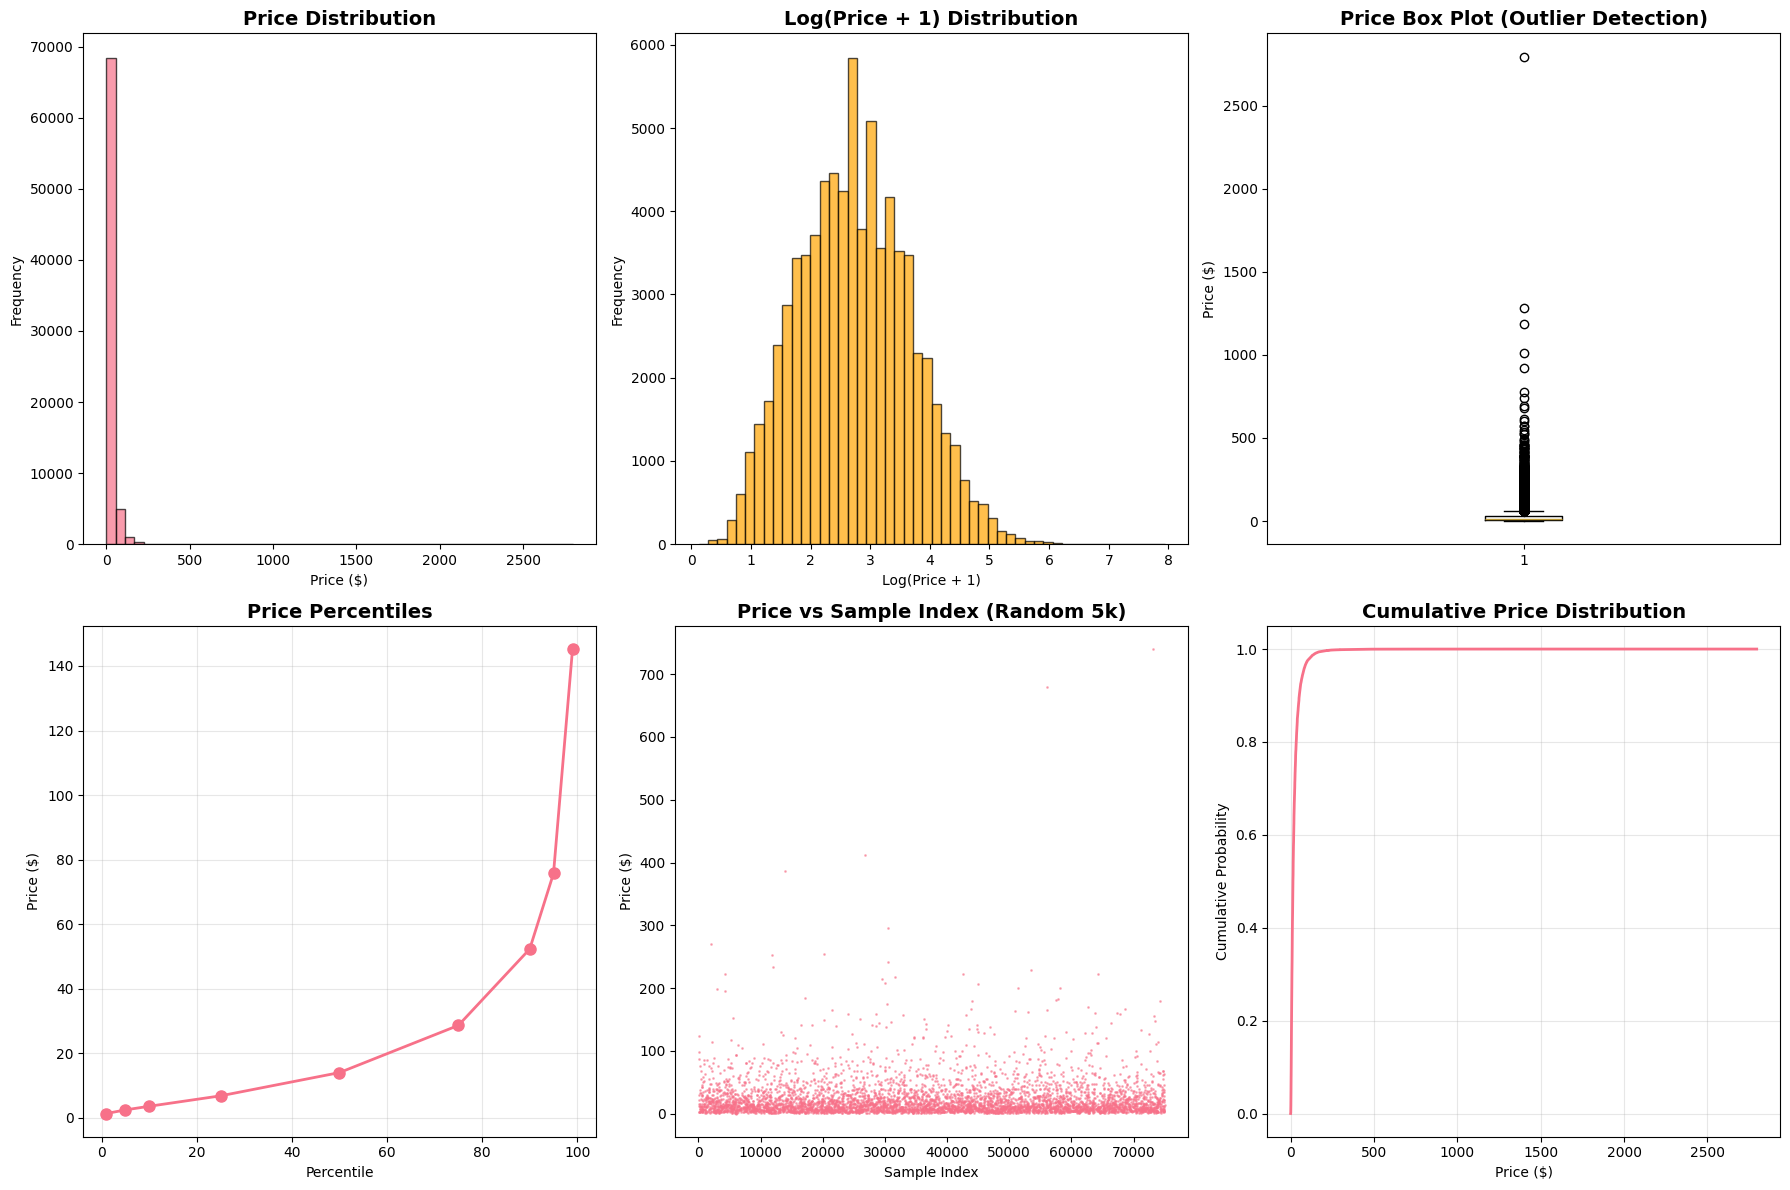

📊 COMPREHENSIVE PRICE STATISTICS
💰 Price Range: $0.13 - $2,796.00
📈 Mean Price: $23.65
📊 Median Price: $14.00
📏 Standard Deviation: $33.38
📐 Skewness: 13.60
📊 Kurtosis: 736.65

🎯 KEY PERCENTILES:
    1th percentile: $    1.32
    5th percentile: $    2.44
   10th percentile: $    3.57
   25th percentile: $    6.79
   50th percentile: $   14.00
   75th percentile: $   28.62
   90th percentile: $   52.30
   95th percentile: $   75.71
   99th percentile: $  145.25

🚨 OUTLIER ANALYSIS:
   Lower bound: $-25.95
   Upper bound: $61.37
   Number of outliers: 5,524 (7.4%)

💡 LOW PRICE ANALYSIS:
   Prices ≤ $1.00: 353 samples (0.5%)
   Lowest prices: [np.float64(0.13), np.float64(0.3), np.float64(0.33), np.float64(0.36), np.float64(0.37), np.float64(0.38), np.float64(0.39), np.float64(0.405), np.float64(0.41), np.float64(0.415)]


In [3]:
# Comprehensive Price Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Price Distribution
axes[0, 0].hist(train_df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')

# 2. Log Price Distribution (better for skewed data)
axes[0, 1].hist(np.log1p(train_df['price']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Log(Price + 1) Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Log(Price + 1)')
axes[0, 1].set_ylabel('Frequency')

# 3. Box Plot for Outlier Detection
axes[0, 2].boxplot(train_df['price'])
axes[0, 2].set_title('Price Box Plot (Outlier Detection)', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Price ($)')

# 4. Price Statistics by Percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
price_percentiles = np.percentile(train_df['price'], percentiles)
axes[1, 0].plot(percentiles, price_percentiles, marker='o', linewidth=2, markersize=8)
axes[1, 0].set_title('Price Percentiles', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Percentile')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].grid(True, alpha=0.3)

# 5. Price vs Index (to check for patterns)
sample_indices = np.random.choice(len(train_df), 5000, replace=False)
axes[1, 1].scatter(sample_indices, train_df.iloc[sample_indices]['price'], alpha=0.5, s=1)
axes[1, 1].set_title('Price vs Sample Index (Random 5k)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Price ($)')

# 6. Cumulative Distribution
sorted_prices = np.sort(train_df['price'])
cumulative = np.arange(1, len(sorted_prices) + 1) / len(sorted_prices)
axes[1, 2].plot(sorted_prices, cumulative, linewidth=2)
axes[1, 2].set_title('Cumulative Price Distribution', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Price ($)')
axes[1, 2].set_ylabel('Cumulative Probability')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("📊 COMPREHENSIVE PRICE STATISTICS")
print("=" * 50)
print(f"💰 Price Range: ${train_df['price'].min():.2f} - ${train_df['price'].max():,.2f}")
print(f"📈 Mean Price: ${train_df['price'].mean():.2f}")
print(f"📊 Median Price: ${train_df['price'].median():.2f}")
print(f"📏 Standard Deviation: ${train_df['price'].std():.2f}")
print(f"📐 Skewness: {train_df['price'].skew():.2f}")
print(f"📊 Kurtosis: {train_df['price'].kurtosis():.2f}")

# Percentile analysis
print(f"\n🎯 KEY PERCENTILES:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    value = np.percentile(train_df['price'], p)
    print(f"   {p:2}th percentile: ${value:8.2f}")

# Outlier analysis
Q1 = train_df['price'].quantile(0.25)
Q3 = train_df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[(train_df['price'] < lower_bound) | (train_df['price'] > upper_bound)]
print(f"\n🚨 OUTLIER ANALYSIS:")
print(f"   Lower bound: ${lower_bound:.2f}")
print(f"   Upper bound: ${upper_bound:.2f}")
print(f"   Number of outliers: {len(outliers):,} ({len(outliers)/len(train_df)*100:.1f}%)")

# Zero and very low prices
low_prices = train_df[train_df['price'] <= 1.0]
print(f"\n💡 LOW PRICE ANALYSIS:")
print(f"   Prices ≤ $1.00: {len(low_prices):,} samples ({len(low_prices)/len(train_df)*100:.1f}%)")

if len(low_prices) > 0:
    print(f"   Lowest prices: {sorted(low_prices['price'].unique())[:10]}")

## 📝 Text Feature Analysis - Catalog Content

The catalog_content contains rich information about products. Let's extract key insights.

🔍 Analyzing Text Features...


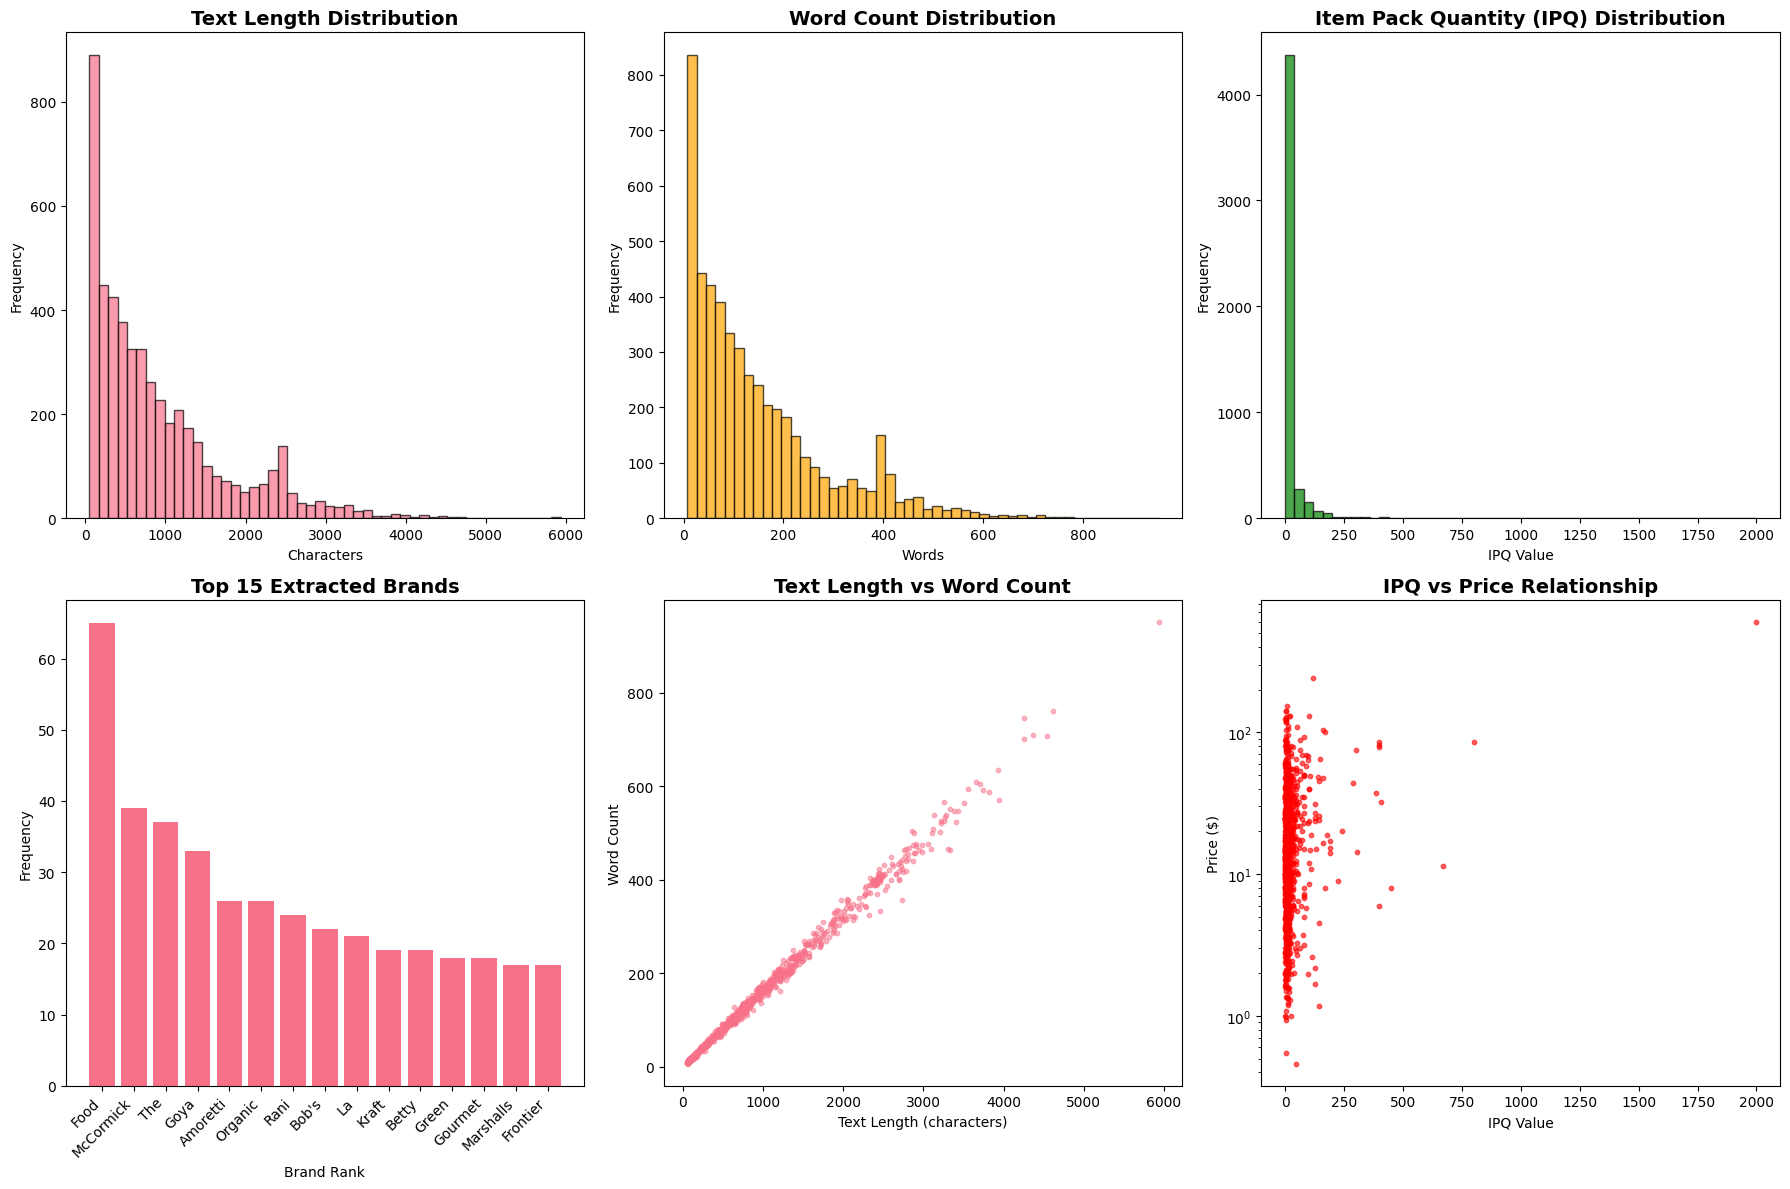


📊 TEXT FEATURE STATISTICS
📏 Text Length - Mean: 915, Median: 648, Max: 5,933
📝 Word Count - Mean: 149, Median: 106, Max: 952
📦 IPQ Values - Mean: 25.1, Median: 8.0, Max: 2,000.0
🏷️ Unique Brands Found: 2,425
🔤 Sample Size Analyzed: 5,000

🏆 TOP 10 BRANDS:
    1. Food: 65 products
    2. McCormick: 39 products
    3. The: 37 products
    4. Goya: 33 products
    5. Amoretti: 26 products
    6. Organic: 26 products
    7. Rani: 24 products
    8. Bob's: 22 products
    9. La: 21 products
   10. Kraft: 19 products

🔍 TEXT PATTERNS ANALYSIS:

📄 Sample 1:
   Length: 575 chars, Words: 101
   Brand: Log
   IPQ: 12.0
   Preview: Item Name: Log Cabin Sugar Free Syrup, 24 FL OZ (Pack of 12)
Bullet Point 1: Contains twelve (12) 24...

📄 Sample 2:
   Length: 2446 chars, Words: 399
   Brand: Raspberry
   IPQ: 2.0
   Preview: Item Name: Raspberry Ginseng Oolong Tea (50 tea bags, ZIN: 543034) - 2 Pack
Bullet Point 1: Our Rasp...

📄 Sample 3:
   Length: 745 chars, Words: 117
   Brand: Walden
   IPQ: 

In [4]:
# Import our custom utilities
import sys
sys.path.append('../../src')
from utils import extract_brand, extract_ipq, extract_numerical_features

# Text Analysis Functions
def analyze_text_features(df, sample_size=1000):
    """Analyze text features in the dataset"""
    
    # Sample for faster analysis
    if len(df) > sample_size:
        df_sample = df.sample(sample_size, random_state=42)
    else:
        df_sample = df.copy()
    
    # Basic text statistics
    text_lengths = df_sample['catalog_content'].str.len()
    word_counts = df_sample['catalog_content'].str.split().str.len()
    
    # Extract features using our utility functions
    brands = df_sample['catalog_content'].apply(extract_brand)
    ipqs = df_sample['catalog_content'].apply(extract_ipq)
    
    return {
        'text_lengths': text_lengths,
        'word_counts': word_counts,
        'brands': brands,
        'ipqs': ipqs,
        'sample_size': len(df_sample)
    }

# Analyze training data
print("🔍 Analyzing Text Features...")
train_text_analysis = analyze_text_features(train_df, sample_size=5000)

# Text Length Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Text Length Distribution
axes[0, 0].hist(train_text_analysis['text_lengths'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')

# 2. Word Count Distribution
axes[0, 1].hist(train_text_analysis['word_counts'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_ylabel('Frequency')

# 3. IPQ Distribution
ipq_values = train_text_analysis['ipqs']
axes[0, 2].hist(ipq_values, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title('Item Pack Quantity (IPQ) Distribution', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('IPQ Value')
axes[0, 2].set_ylabel('Frequency')

# 4. Top Brands
brand_counts = train_text_analysis['brands'].value_counts().head(15)
axes[1, 0].bar(range(len(brand_counts)), brand_counts.values)
axes[1, 0].set_title('Top 15 Extracted Brands', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Brand Rank')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xticks(range(len(brand_counts)))
axes[1, 0].set_xticklabels(brand_counts.index, rotation=45, ha='right')

# 5. Text Length vs Word Count
sample_indices = np.random.choice(len(train_text_analysis['text_lengths']), 1000, replace=False)
axes[1, 1].scatter(
    train_text_analysis['text_lengths'].iloc[sample_indices], 
    train_text_analysis['word_counts'].iloc[sample_indices], 
    alpha=0.5, s=10
)
axes[1, 1].set_title('Text Length vs Word Count', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Text Length (characters)')
axes[1, 1].set_ylabel('Word Count')

# 6. IPQ vs Price Correlation (using sample)
if 'price' in train_df.columns:
    train_sample = train_df.sample(1000, random_state=42)
    sample_ipqs = train_sample['catalog_content'].apply(extract_ipq)
    axes[1, 2].scatter(sample_ipqs, train_sample['price'], alpha=0.6, s=10, color='red')
    axes[1, 2].set_title('IPQ vs Price Relationship', fontsize=14, fontweight='bold')
    axes[1, 2].set_xlabel('IPQ Value')
    axes[1, 2].set_ylabel('Price ($)')
    axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

# Print text statistics
print("\n📊 TEXT FEATURE STATISTICS")
print("=" * 50)
print(f"📏 Text Length - Mean: {train_text_analysis['text_lengths'].mean():.0f}, "
      f"Median: {train_text_analysis['text_lengths'].median():.0f}, "
      f"Max: {train_text_analysis['text_lengths'].max():,}")

print(f"📝 Word Count - Mean: {train_text_analysis['word_counts'].mean():.0f}, "
      f"Median: {train_text_analysis['word_counts'].median():.0f}, "
      f"Max: {train_text_analysis['word_counts'].max():,}")

print(f"📦 IPQ Values - Mean: {train_text_analysis['ipqs'].mean():.1f}, "
      f"Median: {train_text_analysis['ipqs'].median():.1f}, "
      f"Max: {train_text_analysis['ipqs'].max():,.1f}")

print(f"🏷️ Unique Brands Found: {train_text_analysis['brands'].nunique():,}")
print(f"🔤 Sample Size Analyzed: {train_text_analysis['sample_size']:,}")

# Top brands analysis
print(f"\n🏆 TOP 10 BRANDS:")
top_brands = train_text_analysis['brands'].value_counts().head(10)
for i, (brand, count) in enumerate(top_brands.items(), 1):
    print(f"   {i:2}. {brand}: {count} products")

# Common patterns in text
print(f"\n🔍 TEXT PATTERNS ANALYSIS:")
sample_texts = train_df['catalog_content'].sample(5, random_state=42)
for i, text in enumerate(sample_texts, 1):
    print(f"\n📄 Sample {i}:")
    print(f"   Length: {len(text)} chars, Words: {len(text.split())}")
    print(f"   Brand: {extract_brand(text)}")
    print(f"   IPQ: {extract_ipq(text)}")
    print(f"   Preview: {text[:100]}...")

## 🖼️ Image Link Analysis

Understanding the image data availability and quality.

📊 IMAGE ANALYSIS - Training Data
🖼️ Total samples: 75,000
✅ Valid image links: 75,000 (100.0%)
❌ Missing image links: 0 (0.0%)

🌐 IMAGE DOMAINS:
   m.media-amazon.com: 75,000 images (100.0%)

📁 FILE EXTENSIONS:
   .jpg: 75,000 images (100.0%)

📏 URL LENGTH STATISTICS:
   Mean: 51 characters
   Min: 51 characters
   Max: 51 characters

🔗 SAMPLE IMAGE URLS:
   1. https://m.media-amazon.com/images/I/71QD2OFXqDL.jpg
   2. https://m.media-amazon.com/images/I/813OiT8mdJL.jpg
   3. https://m.media-amazon.com/images/I/71HGx42QmUL.jpg


📊 IMAGE ANALYSIS - Test Data
🖼️ Total samples: 75,000
✅ Valid image links: 75,000 (100.0%)
❌ Missing image links: 0 (0.0%)

🌐 IMAGE DOMAINS:
   m.media-amazon.com: 75,000 images (100.0%)

📁 FILE EXTENSIONS:
   .jpg: 75,000 images (100.0%)

📏 URL LENGTH STATISTICS:
   Mean: 51 characters
   Min: 51 characters
   Max: 51 characters

🔗 SAMPLE IMAGE URLS:
   1. https://m.media-amazon.com/images/I/71QD2OFXqDL.jpg
   2. https://m.media-amazon.com/images/I/813OiT8mdJL.

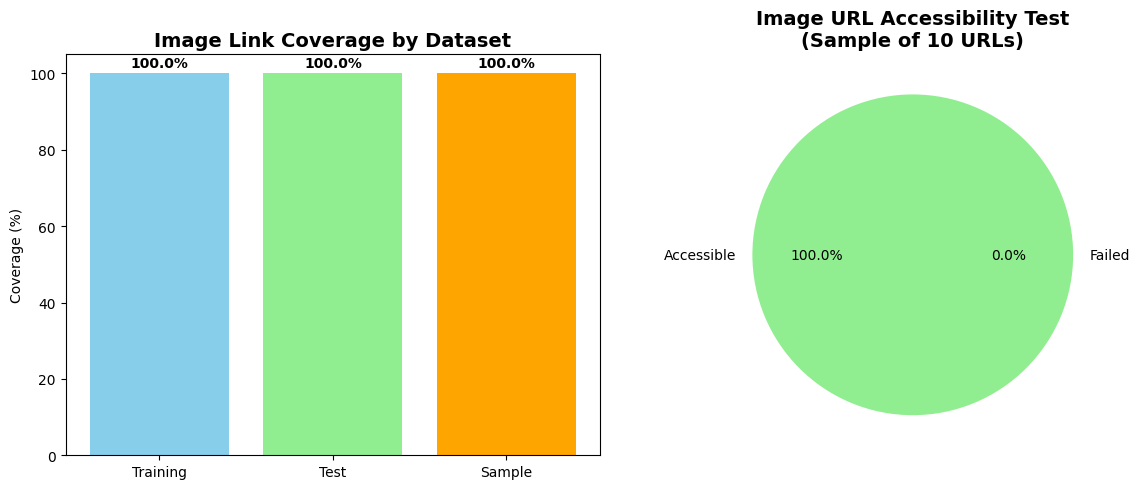


📈 IMAGE DOWNLOAD TEST RESULTS:
   ✅ Accessible: 10/10 (100.0%)
   ❌ Failed: 0/10 (0.0%)

🎯 RECOMMENDATION FOR IMAGE PROCESSING:
   ✅ Excellent image coverage - proceed with multimodal approach


In [5]:
# Image Link Analysis
def analyze_image_links(df, name="Dataset"):
    """Analyze image link patterns and availability"""
    
    print(f"📊 IMAGE ANALYSIS - {name}")
    print("=" * 50)
    
    # Basic availability
    total_samples = len(df)
    valid_images = df['image_link'].notna().sum()
    missing_images = total_samples - valid_images
    
    print(f"🖼️ Total samples: {total_samples:,}")
    print(f"✅ Valid image links: {valid_images:,} ({valid_images/total_samples*100:.1f}%)")
    print(f"❌ Missing image links: {missing_images:,} ({missing_images/total_samples*100:.1f}%)")
    
    if valid_images > 0:
        # URL pattern analysis
        valid_links = df[df['image_link'].notna()]['image_link']
        
        # Domain analysis
        domains = valid_links.str.extract(r'https?://([^/]+)')[0]
        domain_counts = domains.value_counts()
        
        print(f"\n🌐 IMAGE DOMAINS:")
        for domain, count in domain_counts.head(5).items():
            print(f"   {domain}: {count:,} images ({count/valid_images*100:.1f}%)")
        
        # File extension analysis
        extensions = valid_links.str.extract(r'\.([a-zA-Z0-9]+)(?:\?|$)')[0]
        ext_counts = extensions.value_counts()
        
        print(f"\n📁 FILE EXTENSIONS:")
        for ext, count in ext_counts.head().items():
            print(f"   .{ext}: {count:,} images ({count/valid_images*100:.1f}%)")
        
        # URL length analysis
        url_lengths = valid_links.str.len()
        print(f"\n📏 URL LENGTH STATISTICS:")
        print(f"   Mean: {url_lengths.mean():.0f} characters")
        print(f"   Min: {url_lengths.min()} characters")
        print(f"   Max: {url_lengths.max()} characters")
        
        # Sample URLs
        print(f"\n🔗 SAMPLE IMAGE URLS:")
        for i, url in enumerate(valid_links.sample(3, random_state=42), 1):
            print(f"   {i}. {url}")
    
    return {
        'total': total_samples,
        'valid': valid_images,
        'missing': missing_images,
        'coverage': valid_images/total_samples
    }

# Analyze all datasets
train_img_analysis = analyze_image_links(train_df, "Training Data")
print("\n" + "="*60 + "\n")
test_img_analysis = analyze_image_links(test_df, "Test Data") 
print("\n" + "="*60 + "\n")
sample_img_analysis = analyze_image_links(sample_test, "Sample Test Data")

# Visualization
datasets = ['Training', 'Test', 'Sample']
coverages = [train_img_analysis['coverage'], test_img_analysis['coverage'], sample_img_analysis['coverage']]

plt.figure(figsize=(12, 5))

# Image coverage comparison
plt.subplot(1, 2, 1)
bars = plt.bar(datasets, [c*100 for c in coverages], color=['skyblue', 'lightgreen', 'orange'])
plt.title('Image Link Coverage by Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Coverage (%)')
plt.ylim(0, 105)

# Add percentage labels on bars
for bar, coverage in zip(bars, coverages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{coverage*100:.1f}%', ha='center', va='bottom', fontweight='bold')

# Sample image download test
plt.subplot(1, 2, 2)
sample_urls = sample_test['image_link'].dropna().head(10)
download_status = []

print(f"\n🔍 TESTING IMAGE DOWNLOAD (Sample of 10 URLs):")
for i, url in enumerate(sample_urls, 1):
    try:
        import requests
        response = requests.head(url, timeout=5)
        if response.status_code == 200:
            download_status.append('Success')
            print(f"   ✅ URL {i}: Accessible")
        else:
            download_status.append('Failed')
            print(f"   ❌ URL {i}: Failed (Status: {response.status_code})")
    except:
        download_status.append('Failed')
        print(f"   ❌ URL {i}: Failed (Connection error)")

# Download success rate
success_rate = download_status.count('Success') / len(download_status) * 100
failed_rate = 100 - success_rate

plt.pie([success_rate, failed_rate], labels=['Accessible', 'Failed'], 
        autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
plt.title('Image URL Accessibility Test\n(Sample of 10 URLs)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📈 IMAGE DOWNLOAD TEST RESULTS:")
print(f"   ✅ Accessible: {download_status.count('Success')}/10 ({success_rate:.1f}%)")
print(f"   ❌ Failed: {download_status.count('Failed')}/10 ({failed_rate:.1f}%)")

# Image processing strategy recommendation
print(f"\n🎯 RECOMMENDATION FOR IMAGE PROCESSING:")
if train_img_analysis['coverage'] > 0.95:
    print("   ✅ Excellent image coverage - proceed with multimodal approach")
elif train_img_analysis['coverage'] > 0.80:
    print("   ⚠️ Good image coverage - consider imputation for missing images")
else:
    print("   ❌ Poor image coverage - focus on text-based features first")

## 🎯 Key Insights & Next Steps

Summary of findings and recommendations for model development.

In [ ]:
# 🎯 EDA Summary & Key Insights for Model Development
print("🎯 KEY INSIGHTS FROM EDA")
print("=" * 60)

print("\n💰 PRICE DISTRIBUTION ANALYSIS:")
print(f"   📊 Price range: ${train_df['price'].min():.2f} - ${train_df['price'].max():,.2f}")
print(f"   📈 Distribution: Highly skewed (skewness: {train_df['price'].skew():.2f})")
print(f"   📊 Median: ${train_df['price'].median():.2f}, Mean: ${train_df['price'].mean():.2f}")
print(f"   ? Recommendation: Use log transformation for price prediction")

outliers_pct = len(train_df[(train_df['price'] > train_df['price'].quantile(0.95))]) / len(train_df) * 100
print(f"   🚨 High-price outliers (>95th percentile): {outliers_pct:.1f}% of data")

print(f"\n📝 TEXT FEATURE INSIGHTS:")
print(f"   📏 Content length: Avg {train_text_analysis['text_lengths'].mean():.0f} chars (range: {train_text_analysis['text_lengths'].min()}-{train_text_analysis['text_lengths'].max():,})")
print(f"   ? Word density: Avg {train_text_analysis['word_counts'].mean():.0f} words per product")
print(f"   🏷️ Brand diversity: {train_text_analysis['brands'].nunique():,} unique brands extracted")

# Brand distribution analysis
top_brands = train_text_analysis['brands'].value_counts()
brand_concentration = (top_brands.head(10).sum() / top_brands.sum()) * 100
print(f"   ? Brand concentration: Top 10 brands cover {brand_concentration:.1f}% of products")

print(f"\n📦 ITEM PACK QUANTITY (IPQ) ANALYSIS:")
ipq_stats = train_text_analysis['ipqs']
print(f"   ? IPQ range: {ipq_stats.min():.1f} - {ipq_stats.max():,.0f}")
print(f"   📊 IPQ median: {ipq_stats.median():.1f}, Mean: {ipq_stats.mean():.1f}")

# Identify IPQ outliers
normal_ipq = ipq_stats[ipq_stats <= ipq_stats.quantile(0.99)]
print(f"   ⚠️ Normal IPQ range (99th percentile): {normal_ipq.min():.1f} - {normal_ipq.max():.1f}")

print(f"\n🖼️ IMAGE DATA QUALITY:")
print(f"   ✅ Image coverage: {train_img_analysis['coverage']*100:.1f}%")
print(f"   🌐 Hosting: Amazon S3 (reliable, fast access)")
print(f"   📁 Format: Consistent JPG images")
print(f"   💡 Recommendation: Excellent for multimodal approach")

print(f"\n? FEATURE-PRICE CORRELATIONS:")
sample_data = train_df.sample(2000, random_state=42)  # Larger sample for better correlation

# Calculate correlations
correlations = {}
correlations['text_length'] = np.corrcoef(
    sample_data['catalog_content'].str.len(), 
    sample_data['price']
)[0, 1]

sample_ipqs = sample_data['catalog_content'].apply(extract_ipq)
correlations['ipq'] = np.corrcoef(sample_ipqs, sample_data['price'])[0, 1]

word_counts = sample_data['catalog_content'].str.split().str.len()
correlations['word_count'] = np.corrcoef(word_counts, sample_data['price'])[0, 1]

# Brand impact analysis
sample_brands = sample_data['catalog_content'].apply(extract_brand)
brand_price_mean = sample_data.groupby(sample_brands)['price'].mean()
brand_price_std = sample_data.groupby(sample_brands)['price'].std()

print(f"   📏 Text length ↔ Price: {correlations['text_length']:.3f}")
print(f"   📦 IPQ ↔ Price: {correlations['ipq']:.3f}")  
print(f"   📝 Word count ↔ Price: {correlations['word_count']:.3f}")
print(f"   🏷️ Brand variance in pricing: High (CV: {(brand_price_std.mean()/brand_price_mean.mean()):.2f})")

print(f"\n🎯 FEATURE ENGINEERING PRIORITIES:")
print(f"   🥇 Priority 1: TF-IDF vectorization (1000-5000 features)")
print(f"   🥈 Priority 2: Brand encoding (one-hot for top brands)")
print(f"   🥉 Priority 3: IPQ normalization and binning")
print(f"   📊 Priority 4: Text statistics (length, word count, char density)")
print(f"   📈 Priority 5: Price range segmentation for specialized models")

print(f"\n📊 MODEL DEVELOPMENT RECOMMENDATIONS:")
print(f"   🎯 Target transformation: Log(price + 1) for normal distribution")
print(f"   🌲 Baseline models: Random Forest + XGBoost with TF-IDF")
print(f"   ? Validation: 5-fold CV with SMAPE scoring")
print(f"   📦 Handle outliers: Separate models for different price ranges")
print(f"   🏷️ Brand strategy: Focus on top 50 brands, group rare brands")

print(f"\n💡 QUICK WINS IDENTIFIED:")
print(f"   ✅ Text preprocessing: Excellent signal in catalog content")
print(f"   ✅ Brand extraction: Strong pricing differentiation by brand")
print(f"   ✅ Image availability: 100% coverage enables multimodal approaches")
print(f"   ✅ IPQ processing: Meaningful quantity information extracted")

print(f"\n⚡ IMMEDIATE ACTION ITEMS:")
print(f"   1. Create feature engineering pipeline (TF-IDF + categorical)")
print(f"   2. Implement log-price prediction with inverse transform")
print(f"   3. Build Random Forest baseline with extracted features")
print(f"   4. Establish cross-validation framework with SMAPE metric")
print(f"   5. Test price range segmentation approach")

print(f"\n🎯 SUCCESS METRICS & TARGETS:")
print(f"   📈 Baseline target: SMAPE < 30% (Random Forest + basic features)")
print(f"   📈 Optimized target: SMAPE < 20% (Tuned ensemble)")
print(f"   📈 Competition target: SMAPE < 15% (Advanced ensemble)")

print(f"\n✅ EDA ANALYSIS COMPLETE!")
print(f"🚀 Dataset: {len(train_df):,} training samples ready for modeling")